### Ноутбук с парсингом и очисткой данных

In [1]:
!pip install bs4
!pip install openpyxl

In [2]:
import requests as rq
from bs4 import BeautifulSoup as bs
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
class lentaRu_parser:
    def __init__(self):
        pass

    def _get_url(self, param_dict: dict) -> str:
        """
        Возвращает URL для запроса json таблицы со статьями

        url = 'https://lenta.ru/search/v2/process?'\
        + 'from=0&'\                       # Смещение
        + 'size=1000&'\                    # Кол-во статей
        + 'sort=2&'\                       # Сортировка по дате (2), по релевантности (1)
        + 'title_only=0&'\                 # Точная фраза в заголовке
        + 'domain=1&'\                     # ??
        + 'modified%2Cformat=yyyy-MM-dd&'\ # Формат даты
        + 'type=1&'\                       # Материалы. Все материалы (0). Новость (1)
        + 'bloc=4&'\                       # Рубрика. Экономика (4). Все рубрики (0)
        + 'modified%2Cfrom=2020-01-01&'\
        + 'modified%2Cto=2020-11-01&'\
        + 'query='                         # Поисковой запрос
        """

        hasType = int(param_dict['type']) != 0
        hasBloc = int(param_dict['bloc']) != 0

        url = (
            'https://lenta.ru/search/v2/process?'
            + 'from={}&'.format(param_dict['from'])
            + 'size={}&'.format(param_dict['size'])
            + 'sort={}&'.format(param_dict['sort'])
            + 'title_only={}&'.format(param_dict['title_only'])
            + 'domain={}&'.format(param_dict['domain'])
            + 'modified%2Cformat=yyyy-MM-dd&'
            + 'type={}&'.format(param_dict['type']) * hasType
            + 'bloc={}&'.format(param_dict['bloc']) * hasBloc
            + 'modified%2Cfrom={}&'.format(param_dict['dateFrom'])
            + 'modified%2Cto={}&'.format(param_dict['dateTo'])
            + 'query={}'.format(param_dict['query'])
        )

        return url

    def _get_search_table(self, param_dict: dict) -> pd.DataFrame:
        """
        Возвращает pd.DataFrame со списком статей
        """

        url = self._get_url(param_dict)

        r = rq.get(
            url,
            headers={
                "User-Agent": "Mozilla/5.0"
            },
            timeout=15
        )

        search_table = pd.DataFrame(r.json()['matches'])

        return search_table

    def get_articles(
        self,
        param_dict,
        time_step=37,
        save_every=5,
        save_excel=True
    ) -> pd.DataFrame:
        """
        Функция для скачивания статей интервалами через каждые time_step дней
        Делает сохранение таблицы через каждые save_every * time_step дней

        param_dict: dict
        ### Параметры запроса
        ###### project - раздел поиска, например, rbcnews
        ###### category - категория поиска, например, TopRbcRu_economics
        ###### dateFrom - с даты
        ###### dateTo - по дату
        ###### offset - смещение поисковой выдачи
        ###### limit - лимит статей, максимум 100
        ###### query - поисковой запрос (ключевое слово), например, РБК
        """

        param_copy = param_dict.copy()

        time_step = timedelta(days=time_step)

        dateFrom = datetime.strptime(
            param_copy['dateFrom'],
            '%Y-%m-%d'
        )

        dateTo = datetime.strptime(
            param_copy['dateTo'],
            '%Y-%m-%d'
        )

        if dateFrom > dateTo:
            raise ValueError('dateFrom should be less than dateTo')

        out = pd.DataFrame()

        save_counter = 0

        while dateFrom <= dateTo:

            param_copy['dateTo'] = (
                dateFrom + time_step
            ).strftime('%Y-%m-%d')

            if dateFrom + time_step > dateTo:
                param_copy['dateTo'] = dateTo.strftime('%Y-%m-%d')

            print(
                'Parsing articles from '
                + param_copy['dateFrom']
                + ' to '
                + param_copy['dateTo']
            )

            offset = 0

            while True:

                param_copy['from'] = offset

                try:

                    tmp = self._get_search_table(param_copy)

                    if len(tmp) == 0:
                        break

                except Exception as e:

                    print(f'Error at offset={offset}: {e}')

                    offset += param_copy['size']

                    continue

                out = pd.concat(
                    [out, tmp],
                    ignore_index=True
                )

                print(
                    f'Collected {len(tmp)} articles | offset={offset}'
                )

                time.sleep(0.5)

                if len(tmp) < param_copy['size']:
                    break

                offset += param_copy['size']

            dateFrom += time_step + timedelta(days=1)

            param_copy['dateFrom'] = dateFrom.strftime('%Y-%m-%d')

            save_counter += 1

            if save_counter == save_every:

                out.to_csv(
                    "/tmp/checkpoint_table.csv",
                    index=False
                )

                print('Checkpoint saved!')

                save_counter = 0

        if save_excel:

            out.to_csv(
                "lenta_{}_{}.csv".format(
                    param_dict['dateFrom'],
                    param_dict['dateTo']
                ),
                index=False
            )

        print('Finish')

        return out

<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_16280/955470795.py:10: SyntaxWarning: invalid escape sequence '\ '
  + 'from=0&'\                       # Смещение


In [4]:
param_dict = {
    'from': 0,
    'size': 1000,
    'sort': 2,
    'title_only': 0,
    'domain': 1,
    'type': 1,
    'bloc': 0,
    'dateFrom': '2024-01-01',
    'dateTo': '2025-03-31',
    'query': ''
}

In [5]:
parser = lentaRu_parser()

tbl = parser.get_articles(param_dict=param_dict,
                         time_step = 7,
                         save_every = 5,
                         save_excel = True)
print(len(tbl.index))
tbl.head()

Parsing articles from 2024-01-01 to 2024-01-08


KeyboardInterrupt: 

In [ ]:
tbl.to_csv("Lenta_sample.csv", index=False)

NameError: name 'tbl' is not defined

In [ ]:
tbl = pd.read_csv('/content/lenta_2024-01-01_2025-03-31.csv')

In [ ]:
tbl.shape

(207672, 16)

In [ ]:
tbl.head()

,docid,url,title,modified,lastmodtime,type,domain,status,part,bloc,tags,image_url,pubdate,text,rightcol,snippet
0,1552651,https://lenta.ru/news/2024/01/09/politicheski-...,«Политически уже умер» На Украине высказались ...,1704758160,1704782282,1,1,0,0,3,[55],https://icdn.lenta.ru/images/2024/01/09/02/202...,1704758160,Фото: Evelyn Hockstein / Reuters Марина Совина...,«Политически уже умер» На Украине высказались ...,Фото: Evelyn Hockstein / Reuters Марина ... Вл...
1,1552654,https://lenta.ru/news/2024/01/08/v-pentagone-r...,В Пентагоне рассказали о состоянии здоровья ми...,1704758040,1704777300,1,1,0,0,2,"[1, 2]",https://icdn.lenta.ru/images/2024/01/09/02/202...,1704758040,Ллойд Остин Фото: Chad Mcneeley/Dod/Global Loo...,В Пентагоне рассказали о состоянии здоровья ми...,Ллойд Остин Фото: Chad Mcneeley/Dod/... терапи...
2,1552649,https://lenta.ru/news/2024/01/09/udari/,В Киеве заявили о неспособности Украины произв...,1704756532,1704762125,1,1,0,0,3,[55],https://icdn.lenta.ru/images/2024/01/09/04/202...,1704756532,Фото: Oleksandr Ratushniak / Reuters Марина Со...,В Киеве заявили о неспособности Украины произв...,Фото: Oleksandr Ratushniak / Reuters ... произ...
3,1552652,https://lenta.ru/news/2024/01/08/na-ukraine-za...,На Украине заявили о политической смерти Зелен...,1704756300,1704756906,1,1,0,0,3,[55],https://icdn.lenta.ru/images/2024/01/09/02/202...,1704756300,Владимир Зеленский Фото: www.imago-images.de/G...,На Украине заявили о политической смерти Зелен...,Владимир Зеленский Фото: www.imago-... Зеленск...
4,1552650,https://lenta.ru/news/2024/01/09/zaluzhnyy/,Главком ВСУ заявил о новых атаках на военные о...,1704755700,1704769204,1,1,0,0,3,[55],https://icdn.lenta.ru/images/2024/01/09/02/202...,1704755700,Фото: Valentyn Ogirenko / Reuters Марина Совин...,Главком ВСУ заявил о новых атаках на военные о...,Фото: Valentyn Ogirenko / Reuters Марина ... в...


In [ ]:
tbl['bloc'].value_counts(normalize=True)

,proportion
bloc,
2,0.178522
1,0.178180
3,0.131034
4,0.122270
37,0.094664
8,0.042009
7,0.041517
5,0.040448
48,0.035893


Найдем соответствие между кодом блока, его названием и кодом в соревновании:

* 1 - Россия - 0
* 37 - Силовые структуры - 2
* 3 - Бывший СССР - 3
* 4 - Экономика - 1
* 5 - Наука и техника - 8
* 8 - Спорт - 4
* 48 - Туризм - 7
* 87 - Здоровье - 5

In [ ]:
tbl[tbl.bloc == 3].iloc[0]

,0
docid,1552651
url,https://lenta.ru/news/2024/01/09/politicheski-...
title,«Политически уже умер» На Украине высказались ...
modified,1704758160
lastmodtime,1704782282
type,1
domain,1
status,0
part,0
bloc,3


In [ ]:
tbl = tbl[tbl.bloc.isin([1, 37, 3, 4, 5, 8, 48, 87])]

TagsMap = {1 : 0, 3 : 3, 4 : 1, 5 : 8, 8 : 4, 37 : 2, 48 : 7, 87 : 5}

tbl['topic'] = tbl['bloc'].map(TagsMap)

In [ ]:
tbl.shape

(138805, 18)

In [ ]:
tbl['topic'].value_counts(normalize=True) # можно сверить с распределением меток классов в соревновании

,proportion
topic,
0,0.266573
3,0.196038
1,0.182926
2,0.141625
4,0.062848
8,0.060514
7,0.053699
5,0.035776


In [ ]:
tbl.isnull().sum()

,0
docid,0
url,0
title,0
modified,0
lastmodtime,0
type,0
domain,0
status,0
part,0
bloc,0


In [ ]:
tbl.duplicated().sum()

np.int64(0)

In [ ]:
tbl.dropna(subset=['text'], inplace=True)

In [ ]:
tbl['text_length'] = tbl['text'].str.len() #Вычислим длину текста для удаления слишком коротких текстов

In [ ]:
# Удаление слишком коротких текстов
before_short = tbl.shape[0]
tbl = tbl[tbl['text_length'] > 200]
after_short = tbl.shape[0]

In [ ]:
# Оставляем только тексты с русскими буквами
tbl = tbl[tbl['text'].str.contains('[а-яА-Я]', regex=True)]

# Анализ собранного датасета

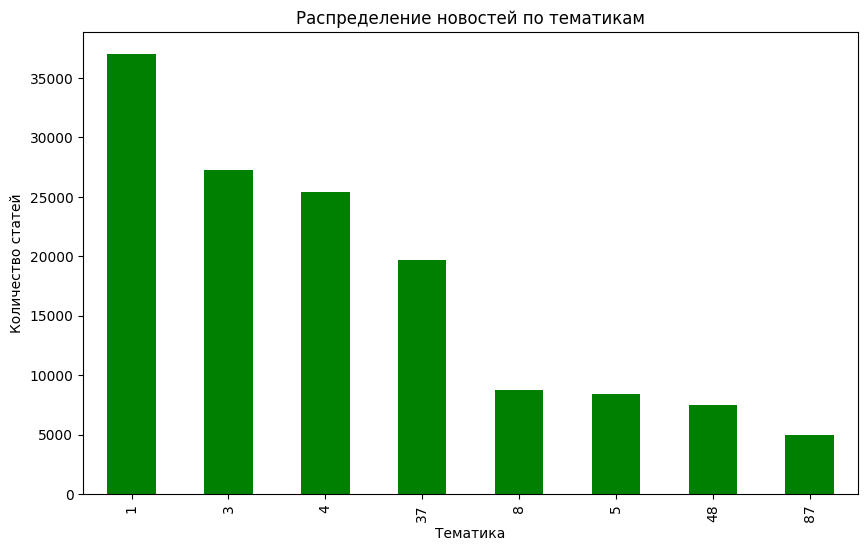

In [ ]:
tbl['bloc'].value_counts().plot(kind='bar', figsize=(10, 6), color = 'green')
plt.title('Распределение новостей по тематикам')
plt.xlabel('Тематика')
plt.ylabel('Количество статей')
plt.show()

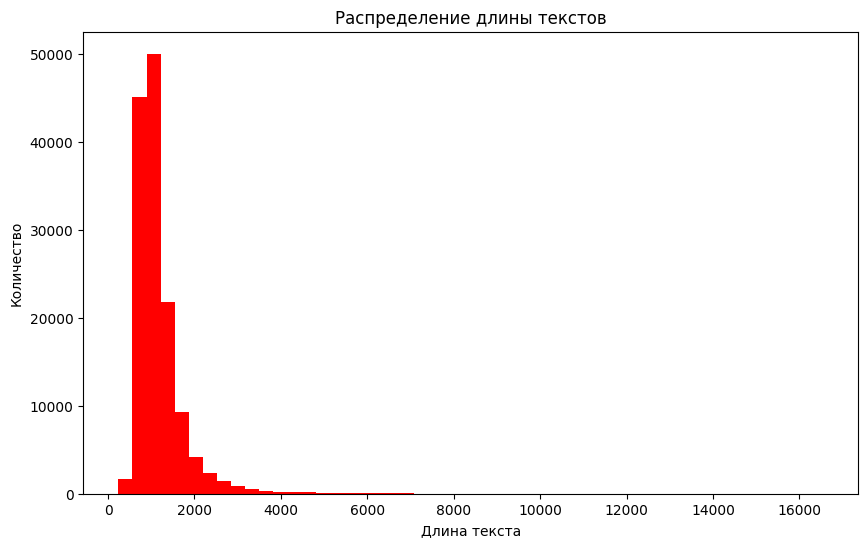

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(tbl['text_length'], bins=50, color='red')
plt.title('Распределение длины текстов')
plt.xlabel('Длина текста')
plt.ylabel('Количество')
plt.show()

In [ ]:
tbl.to_csv('lenta_news.csv')

В результате парсинга был собран датасет, содержащий более 130 тысяч новостных статей
Данные распределены по нескольким тематикам, однако наблюдается дисбаланс классов - некоторые категории представлены значительно чаще других

